In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths
sumprom_chec_glob = "sumproms/*.gz"

## Imports

In [3]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import ScalarMappable, get_cmap
from matplotlib.colors import BoundaryNorm, ListedColormap, Normalize
from scipy.stats import zscore

## Family definitions

In [4]:
FOXK1_WT = ["FOXP3", "FOXA2", "FOXF1", "FOXL1", "FOXL2", "FOXJ2", "FOXO3", "FOXP1", "FOXP2"]
GABPA_WT = ["ELF1", "ELF2", "ERF1", "ELK1", "ELK4", "ERG", "FLI1"]
SOX10_WT = ["SOX15", "SOX17", "SOX7", "SOX11", "SOX4", "SOX6", "SOX30", "SOX9", "SOX13", "SOX5"]
HXD10_WT = ["CDX2", "HOXA11", "HOXC10", "HOXD9", "HOXA10", "HOXC9", "HOXA9", "HOXB9", "CDX4", "HOXC13"]
GATA1_WT = ["GATA3", "GATA6", "GATA4", "GATA2", "GATA5"]
BATF3_WT = ["ATF4", "FOS", "CREB5", "ATF1", "CREB1", "ATF2"]
HEY1_WT = ["MNT", "MLXIPL", "MLX", "MXD4"]
NFAC4_WT = ["NFATC4", "NFATC3"]
TF2LY_WT = ["TGIF2LX", "TGIF2LY", "TGIF1", "TGIF2"]
PO3F2_WT = ["POU2F3", "POU3F4", "POU3F1"]

dbd_fam_dict = {
    "FOXK1": FOXK1_WT,
    "GABPA": GABPA_WT,
    "SOX10": SOX10_WT,
    "HXD10": HXD10_WT,
    "GATA1": GATA1_WT,
    "BATF3": BATF3_WT,
    "HEY1": HEY1_WT,
    "NFAC4": NFAC4_WT,
    "TF2LY": TF2LY_WT,
    "PO3F2": PO3F2_WT,
}

dbd_type = {
    "BATF3": "bZIP",
    "FOXK1": "Forkhead",
    "GABPA": "ETS",
    "HEY1": "bHLH",
    "HXD10": "Homeodomain\nHOX",
    "NFAC4": "Rel",
    "SOX10": "Sox",
    "TF2LY": "Homeodomain\nTALE-Type",
    "PO3F2": "Homeodomain\nPOU",
    "GATA1": "GATA",
}

exists_in_yeast = {
    "FOXK1": "yes",
    "GABPA": "no",
    "SOX10": "no",
    "HXD10": "no",
    "GATA1": "yes",
    "BATF3": "yes",
    "HEY1": "yes",
    "NFAC4": "no",
    "TF2LY": "no",
    "PO3F2": "no",
}

obligate_dimer_dbd = {
    "FOXK1": "no",
    "GABPA": "no",
    "SOX10": "no",
    "HXD10": "no",
    "GATA1": "no",
    "BATF3": "yes",
    "HEY1": "yes",
    "NFAC4": "no",
    "TF2LY": "no",
    "PO3F2": "no",
}

fam_plot_order = ["FOXK1", "BATF3", "GATA1", "HEY1", "GABPA", "NFAC4", "TF2LY", "PO3F2", "HXD10", "SOX10"]

## Helper functions

In [5]:
# Keep only reproducible replicate columns within each TF group
def filter_reproducible(sumprom_all: pd.DataFrame, cutoff):
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]

    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)
    return df[keep]

## Data loading

In [6]:
# Load promoter signal tables from all sequencing batches
sumprom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in sumprom_chec_files], axis=1)

## Data processing

In [7]:
# Filter reproducible samples and average replicates
corr_cutoff = 0.895
sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)

# Average replicates for each TF and compute z-scores
cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit("_", n=2).str[0]
sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
sumprom_z = sumprom.apply(zscore)

# Compute the maximum replicate correlation per TF
df = sumprom_all.copy()
base = df.columns.str.rsplit("_", n=2).str[0]

max_corrs = {}
for b, cols in df.columns.to_series().groupby(base):
    if len(cols) > 1:
        c = df[cols].corr()
        m = c.values.copy()
        np.fill_diagonal(m, np.nan)
        max_corrs[b] = np.nanmax(m)
    else:
        max_corrs[b] = np.nan

# Summarize promoter binding above the z-score cutoff
z_cutoff = 3
sum_sumprom_zgt3 = np.log2((sumprom * (sumprom_z > z_cutoff)).sum())

## Plotting

/tmp/ipykernel_3622358/3718004062.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = get_cmap("YlOrBr")
/tmp/ipykernel_3622358/3718004062.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bind_cmap = get_cmap("Blues")


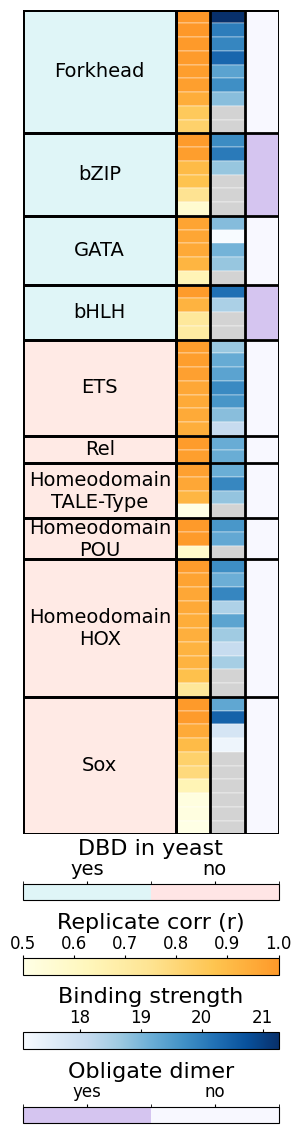

In [8]:
# Plot the family summary heatmap with replicate correlation, binding strength, and obligate dimer status
def plot_dimer_status_summary():
    # Collect samples in the plotted order
    all_samples = []
    for fam in fam_plot_order:
        all_samples.extend(sorted(dbd_fam_dict[fam], key=lambda x: max_corrs[x], reverse=True))

    vals = np.array([max_corrs[s] for s in all_samples])
    norm = Normalize(vmin=0.5, vmax=1)

    base_cmap = get_cmap("YlOrBr")
    scaled_cmap = ListedColormap(base_cmap(np.linspace(0, 0.5, 256)))
    cmap = lambda v: scaled_cmap(norm(v))

    # Set panel geometry
    cell_h = 0.65
    fam_w = 1.8
    sample_w = 0.4
    binding_w = 0.4
    od_w = 0.4
    total_h = cell_h * len(all_samples)
    total_w = fam_w + sample_w + binding_w + od_w

    fig, ax = plt.subplots(figsize=(total_w, total_h * 0.3))
    ax.axis("off")
    y = total_h

    # Prepare the binding-strength colormap
    bind_vals = sum_sumprom_zgt3.reindex(all_samples)
    non_null = bind_vals.dropna()
    if len(non_null) > 0:
        bind_vmin = float(non_null.min())
        bind_vmax = float(non_null.max())
        if bind_vmin == bind_vmax:
            bind_vmin = bind_vmin - 1e-6
    else:
        bind_vmin, bind_vmax = 0.0, 1.0

    bind_norm = Normalize(vmin=bind_vmin, vmax=bind_vmax)
    bind_cmap = get_cmap("Blues")

    # Draw one block per DBD family
    for fam in fam_plot_order:
        samples = sorted(dbd_fam_dict[fam], key=lambda x: max_corrs[x], reverse=True)
        n = len(samples)
        fam_h = cell_h * n
        fam_start_y = y - fam_h

        # Replicate-correlation column
        y2 = y
        for s in samples:
            y2 -= cell_h
            ax.add_patch(plt.Rectangle((fam_w, y2), sample_w, cell_h, color=cmap(max_corrs[s]), ec="white", lw=0.3))

        # Binding-strength column
        y3 = y
        for s in samples:
            y3 -= cell_h
            bval = None
            if s in sum_sumprom_zgt3.index:
                bval = sum_sumprom_zgt3.loc[s]
            if pd.isna(bval):
                bcolor = "lightgrey"
                edgecolor = "white"
                lw = 0.3
            else:
                bcolor = bind_cmap(bind_norm(float(bval)))
                edgecolor = "white"
                lw = 0.3
            ax.add_patch(plt.Rectangle((fam_w + sample_w, y3), binding_w, cell_h, color=bcolor, ec=edgecolor, lw=lw))

        # Family label block
        fam_color = "#DFF5F7" if exists_in_yeast[fam] == "yes" else "#FFEAE5"
        ax.add_patch(plt.Rectangle((0, fam_start_y), fam_w, fam_h, color=fam_color, ec="black", lw=2))
        ax.text(fam_w / 2, fam_start_y + fam_h / 2, dbd_type[fam], ha="center", va="center", fontsize=14)

        # Obligate-dimer block
        od_flag = str(obligate_dimer_dbd[fam]).strip().lower()
        od_color = "#D5C5F0" if od_flag == "yes" else "ghostwhite"
        ax.add_patch(plt.Rectangle((fam_w + sample_w + binding_w, fam_start_y), od_w, fam_h, color=od_color, ec="white", lw=0.3))

        y = fam_start_y

    # Draw separators and outer border
    y_line = total_h
    for fam in fam_plot_order:
        ax.plot([0, total_w], [y_line, y_line], color="black", linewidth=2)
        y_line -= cell_h * len(dbd_fam_dict[fam])
    ax.plot([0, total_w], [y_line, y_line], color="black", linewidth=2)

    ax.plot([fam_w, fam_w], [0, total_h], color="black", linewidth=2)
    ax.plot([fam_w + sample_w, fam_w + sample_w], [0, total_h], color="black", linewidth=2)
    ax.plot([fam_w + sample_w + binding_w, fam_w + sample_w + binding_w], [0, total_h], color="black", linewidth=2)
    ax.plot([total_w, total_w], [0, total_h], color="black", linewidth=2)
    ax.add_patch(plt.Rectangle((0, 0), total_w, total_h, fill=False, ec="black", lw=2))

    ax.set_xlim(0, total_w)
    ax.set_ylim(0, total_h)

    # Build stacked colorbars
    yeast_cmap = ListedColormap(["#FFE5E5", "#DFF5F7"]).reversed()
    yeast_norm = BoundaryNorm([0, 0.5, 1], yeast_cmap.N)
    sm_yeast = ScalarMappable(norm=yeast_norm, cmap=yeast_cmap)
    sm_yeast.set_array([])

    sm = ScalarMappable(norm=norm, cmap=scaled_cmap)
    sm.set_array([])

    sm_bind = ScalarMappable(norm=bind_norm, cmap=bind_cmap)
    sm_bind.set_array([])

    od_cmap = ListedColormap(["ghostwhite", "#D5C5F0"]).reversed()
    od_norm = BoundaryNorm([0, 0.5, 1], od_cmap.N)
    sm_od = ScalarMappable(norm=od_norm, cmap=od_cmap)
    sm_od.set_array([])

    cax1 = ax.inset_axes([0.0, -0.08, 1.0, 0.02])
    cax2 = ax.inset_axes([0.0, -0.17, 1.0, 0.02])
    cax3 = ax.inset_axes([0.0, -0.26, 1.0, 0.02])
    cax4 = ax.inset_axes([0.0, -0.35, 1.0, 0.02])

    cb1 = plt.colorbar(sm_yeast, cax=cax1, orientation="horizontal")
    cb1.ax.xaxis.set_ticks_position("top")
    cb1.ax.xaxis.set_label_position("top")
    cb1.set_label("DBD in yeast", fontsize=16, labelpad=3)
    cb1.set_ticks([0.25, 0.75])
    cb1.set_ticklabels(["yes", "no"])
    cb1.ax.tick_params(labelsize=14, length=2, pad=2)

    cb2 = plt.colorbar(sm, cax=cax2, orientation="horizontal")
    cb2.ax.xaxis.set_ticks_position("top")
    cb2.ax.xaxis.set_label_position("top")
    cb2.set_label("Replicate corr (r)", fontsize=16, labelpad=4)
    cb2.ax.tick_params(labelsize=12, length=2, pad=2)

    cb3 = plt.colorbar(sm_bind, cax=cax3, orientation="horizontal")
    cb3.ax.xaxis.set_ticks_position("top")
    cb3.ax.xaxis.set_label_position("top")
    cb3.set_label("Binding strength", fontsize=16, labelpad=4)
    cb3.ax.tick_params(labelsize=12, length=2, pad=2)

    cb4 = plt.colorbar(sm_od, cax=cax4, orientation="horizontal")
    cb4.ax.xaxis.set_ticks_position("top")
    cb4.ax.xaxis.set_label_position("top")
    cb4.set_label("Obligate dimer", fontsize=16, labelpad=4)
    cb4.set_ticks([0.25, 0.75])
    cb4.set_ticklabels(["yes", "no"])
    cb4.ax.tick_params(labelsize=12, length=2, pad=2)

    plt.tight_layout()
    plt.show()


plot_dimer_status_summary()